In [2]:
# lin alg for microarray data
library(limma)
library(jsonlite)

In [3]:
# load .rds saved datasets into variables
expr <- readRDS("../datasets/expression_matrix_train.rds")
clinical <- readRDS("../datasets/clinical_metadata_train.rds")

head(expr)
dim(expr)

head(clinical)
tail(clinical)
dim(clinical)

,Gene Symbol,GSM1045191,GSM1045192,GSM1045193,GSM1045194,GSM1045195,GSM1045196,GSM1045197,GSM1045198,GSM1045199,⋯,GSM1045302,GSM1045303,GSM1045304,GSM1045305,GSM1045306,GSM1045307,GSM1045308,GSM1045309,GSM1045310,GSM1045311
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,A1BG,5.061765,5.384287,5.462018,5.104647,4.940101,5.087535,5.647719,5.502169,4.935021,⋯,5.612234,5.074677,6.872525,8.020731,5.132484,5.815884,5.310448,5.293781,5.683640,5.880834
2,A1BG-AS1,4.213439,4.497735,5.442854,4.142935,3.836375,3.840813,4.108047,4.117811,4.374573,⋯,5.274847,4.386748,5.158049,4.650182,4.528774,4.627988,4.577176,4.533182,4.283014,4.635586
3,A1CF,2.960794,3.844863,3.603847,3.710878,2.919968,3.246907,2.954523,3.181512,3.115969,⋯,3.695726,3.247118,3.037334,3.657515,3.350718,2.967194,2.943969,3.404410,3.238819,2.898562
4,A2M,6.814863,6.845371,4.532851,7.000975,7.117619,6.683618,6.839982,7.182724,6.365128,⋯,5.206523,6.804822,6.542975,5.768323,5.881436,6.835486,6.455288,6.328355,6.584059,6.576534
5,A2M-AS1,4.973031,4.252506,3.920574,4.064233,5.378826,5.553602,5.198546,5.391066,5.675315,⋯,3.974318,4.694706,4.407413,3.791085,3.544270,4.649494,3.700493,3.785728,3.637337,4.267453
6,A2ML1,3.133812,3.408455,3.779359,3.546180,3.138060,3.030034,3.338255,3.241485,3.111028,⋯,4.034024,3.141456,3.195094,3.162890,3.291446,2.894613,2.764031,3.472512,3.094196,3.243091


[1] 21655   122

,sample_id,tissue_type,patient_age,tumor_grade,tumor_size,er_status,lymph_node_status,relapse_free_event,relapse_free_days
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GSM1045191,GSM1045191,normal breast,NA,NA,NA,NA,NA,NA,NA
GSM1045192,GSM1045192,normal breast,NA,NA,NA,NA,NA,NA,NA
GSM1045193,GSM1045193,normal breast,NA,NA,NA,NA,NA,NA,NA
GSM1045194,GSM1045194,normal breast,NA,NA,NA,NA,NA,NA,NA
GSM1045195,GSM1045195,normal breast,NA,NA,NA,NA,NA,NA,NA
GSM1045196,GSM1045196,normal breast,NA,NA,NA,NA,NA,NA,NA


,sample_id,tissue_type,patient_age,tumor_grade,tumor_size,er_status,lymph_node_status,relapse_free_event,relapse_free_days
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GSM1045306,GSM1045306,breast cancer,60.39,3,6,0,1,1,634
GSM1045307,GSM1045307,breast cancer,46.09,2,2,1,1,0,2952
GSM1045308,GSM1045308,breast cancer,47.82,1,3,NA,1,1,1209
GSM1045309,GSM1045309,breast cancer,48.43,2,3.5,1,1,0,2105
GSM1045310,GSM1045310,breast cancer,70.44,2,2,1,1,1,639
GSM1045311,GSM1045311,breast cancer,62.51,2,1.5,1,1,0,2962


[1] 121   9

In [4]:
# create an array of each sample's tissue type to be mapped to design matrix
groups <- factor(clinical$tissue_type)
levels(groups)

# create design matrix and label columns
design <- model.matrix(~ 0 + groups)
colnames(design) <- c('tumor', 'normal')

head(design)
tail(design)

[1] "breast cancer" "normal breast"

,tumor,normal
1,0,1
2,0,1
3,0,1
4,0,1
5,0,1
6,0,1


,tumor,normal
116,1,0
117,1,0
118,1,0
119,1,0
120,1,0
121,1,0


In [5]:
# define contrast matrix (how will be compare tumor vs normal)?
# diff = tumor exp - normal exp
# showing over expression/under expression in a tumor vs normal (like control vs experimental)

contrast <- makeContrasts(tumor_vs_normal = tumor-normal, levels=design)
contrast

,tumor_vs_normal
tumor,1
normal,-1


In [6]:
# fit expression matrix to linear model
fit <- lmFit(expr, design)

# computing the contrast
fit_contrast <- contrasts.fit(fit, contrast)

# what does lmFit() do?
#   - t-test is a linear model, it's giving slop formula
#   - this is a cool, interesting way of computing it by fitting a non linear curve to a line
# contrast?
#   - again, to get the difference in expression not just the expression

Converting data.frame to matrix, treating first column as gene IDs.



In [7]:
# find DEGs using bayesian stats
fit_contrast <- eBayes(fit_contrast)

# generate a list of all differentially expressed genes
all_genes <- topTable(fit_contrast, number = Inf, adjust = "BH")
dim(all_genes)

# filter out for all significant DEGs
deg_genes <- all_genes[
    all_genes$P.Value < 0.05 &
    all_genes$adj.P.Val < 0.05 &
    abs(all_genes$logFC) > 1,
]
dim(deg_genes)
head(deg_genes)

# make dataframe into list of gene symbols
deg_genes_list <- deg_genes$Gene.Symbol

# eBayes
#   - moderated t: shrinks standard error using empirical Bayes
#   - moderated f: tests multiple coeffs/conditions
#   - empirical bayes: variance shrink, posterior (shrunken) variance estimate
#   - p-val adjust: Benjamini-Hochberg FDR


[1] 21655     7

[1] 1557    7

,Gene.Symbol,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10959,LOC284825,-3.529673,3.781575,-22.30632,7.904608e-45,1.711743e-40,91.37392
19330,TMEM132C,-2.881126,5.439432,-20.66452,1.265697e-41,1.370433e-37,84.12062
212,ACADL,-2.997806,3.668408,-20.17125,1.239943e-40,8.950324e-37,81.87387
279,ACSM5,-2.490258,4.296128,-20.01519,2.568701e-40,1.390630e-36,81.15648
7774,HSPB7,-1.680985,4.263000,-19.76829,8.182186e-40,3.522458e-36,80.01503
13932,PDE3B,-3.370559,4.067125,-19.72585,9.992881e-40,3.522458e-36,79.81803


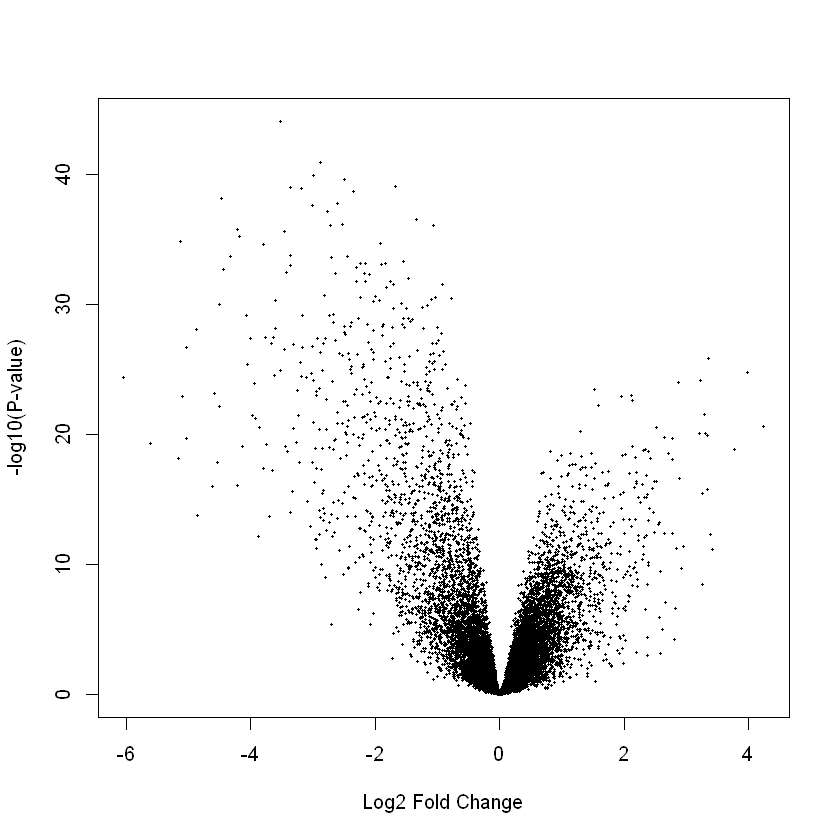

In [8]:
# generate a vocalno plot to visualize differential expression
volcanoplot(fit_contrast)

In [9]:
# download all immune genes
immune_data <- fromJSON("../data/immune_genes.json")

# explore structure
str(immune_data)

'data.frame':	153 obs. of  5 variables:
 $ name  : chr  "Activation of innate immune response" "Adaptive immune memory response" "Adaptive immune memory response involving T cells and B cells" "Adaptive immune response based on somatic recombination of immune receptors built from immunoglobulin superfamily domains" ...
 $ id    : chr  "GO:0002218" "GO:0090716" "GO:0090717" "GO:0002460" ...
 $ source: chr  "GO" "GO" "GO" "GO" ...
 $ link  : chr  "https://amigo.geneontology.org/amigo/term/GO:0002218" "https://amigo.geneontology.org/amigo/term/GO:0090716" "https://amigo.geneontology.org/amigo/term/GO:0090717" "https://amigo.geneontology.org/amigo/term/GO:0002460" ...
 $ count : chr  "164" "3" "3" "162" ...


In [10]:
# extract a list of ALL immune genes

# url used by immport to download Go and Reactome gene data
base_url <- "https://s3.immport.org/release/genelists/current/"
immune_genes <- list()

for (i in 1:nrow(immune_data)) {
  id <- immune_data$id[i]
  url <- paste0(base_url, id, ".json")
  
  # try to read JSON & skip if not available
  try({
    json_data <- fromJSON(url)
    gene_symbol = json_data$genes$Symbol
    if (!is.null(gene_symbol)) {
      immune_genes[[id]] <- gene_symbol
    }
  }, silent = TRUE)
}

# flatten into a single unique vector containing a list of all immune genes
immune_genes <- unique(unlist(immune_genes))

In [11]:
# read in files cancer genes and transcription factors
tf_df <- read.csv('../data/transcription_factors.csv')

# extract list of tumor related transcription factors
tumor_tf <- tf_df$Target_Gene

length(tumor_tf)

[1] 9396

In [12]:
# filter for immune and tumor related transcription factors
immune_deg_genes <- intersect(deg_genes_list, immune_genes)
tumor_tf_deg_genes <- intersect(deg_genes_list, tumor_tf)

length(immune_deg_genes)
length(tumor_tf_deg_genes)

# filter dataframe to only include separate immune & tumor tf genes
immune_deg_df <- deg_genes[deg_genes$Gene.Symbol %in% immune_deg_genes, ]
tumor_tf_deg_df <- deg_genes[deg_genes$Gene.Symbol %in% tumor_tf_deg_genes, ]

dim(immune_deg_df)
dim(tumor_tf_deg_df)

[1] 261

[1] 327

[1] 261   7

[1] 327   7

In [13]:
# combine both datasets into one deg dataset
deg_df_combined <- rbind(immune_deg_df, tumor_tf_deg_df)

# create datasets directory if it doesn't exist
dir.create("../datasets", recursive = TRUE, showWarnings = FALSE)

# save datasets in datasets folder for persistent storage
saveRDS(deg_df_combined, "../datasets/deg_train.rds")